In [9]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from skimage import util
from skimage.filters import threshold_otsu
from skimage.io import imread
from skimage.measure import label, regionprops_table
from skimage.morphology import closing, disk, opening, remove_small_holes
from skimage.segmentation import expand_labels


In [10]:
image_folder = Path(r"Z:\\Bel\\Marina_Area_PDO\\260310")
images = sorted(image_folder.glob("*.png"))
segmented_stack = imread(image_folder / "marina_segmented_stack.tif")

if len(images) != segmented_stack.shape[0]:
    raise ValueError(
        f"Found {len(images)} PNG images but {segmented_stack.shape[0]} segmentation slices."
    )

image FL12_ARI_day6_4x_dev1_0037_TRANS.png: method=Segmentation, solidity=0.961, area=1086165 px


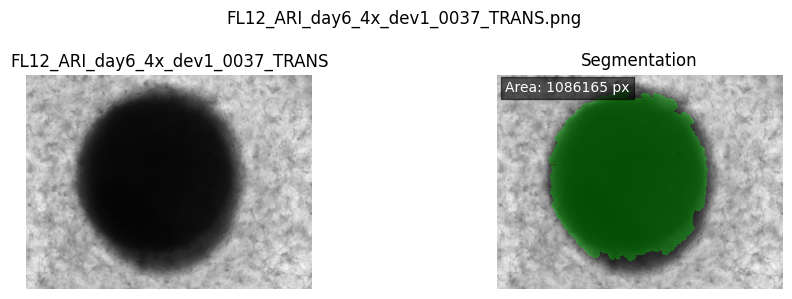

image FL12_ARI_day6_4x_dev2_0036_TRANS.png: method=Segmentation, solidity=0.960, area=783012 px


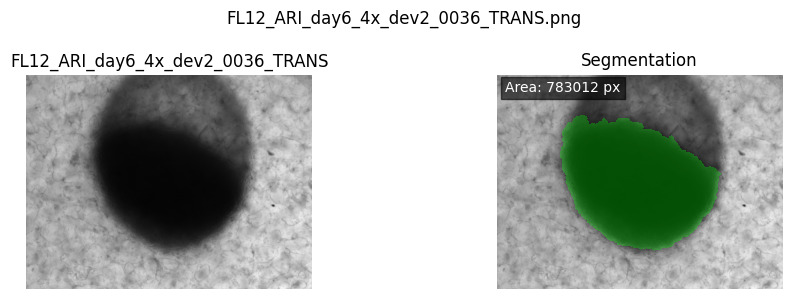

image FL12_ARI_day6_4x_dev3_0035_TRANS.png: method=Segmentation (Extra Opening), solidity=0.895, area=565941 px


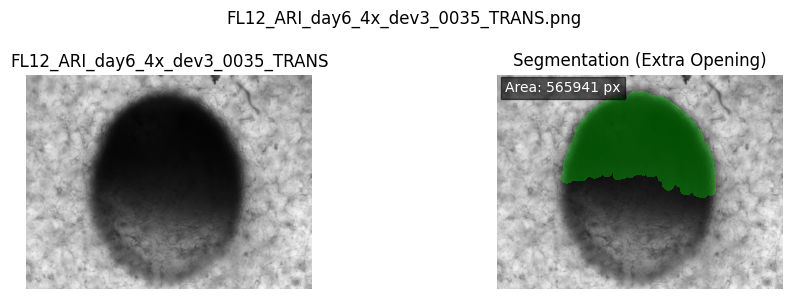

image FL12_ARI_day6_4x_dev4_0034_TRANS.png: method=Segmentation, solidity=0.956, area=1093949 px


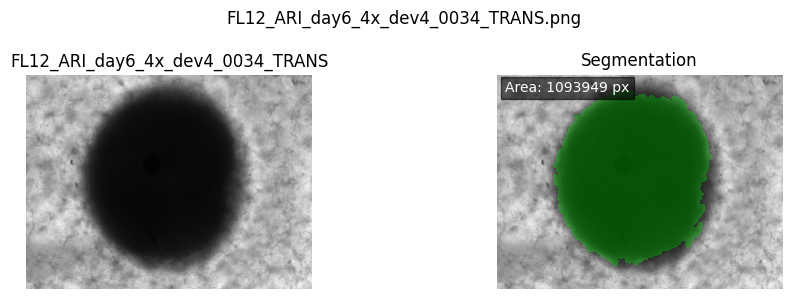

image FL12_ARI_day6_4x_dev5_0033_TRANS.png: method=Segmentation, solidity=0.962, area=1002004 px


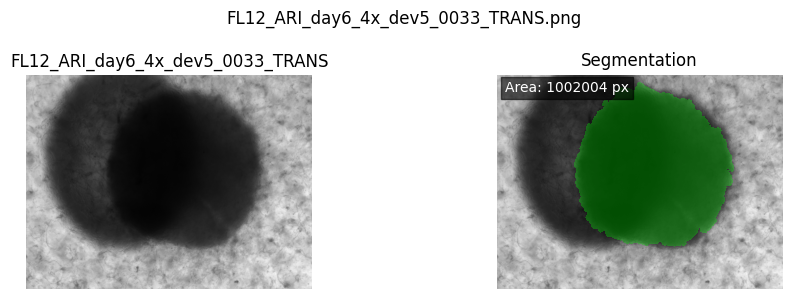

image FL12_ARI_day6_4x_dev6_0032_TRANS.png: method=Segmentation (Extra Opening), solidity=0.932, area=919755 px


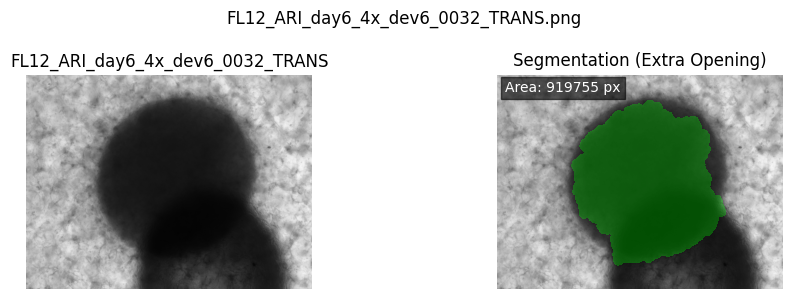

image FL12_ARI_day6_4x_dev7_0031_TRANS.png: method=Segmentation, solidity=0.953, area=1043727 px


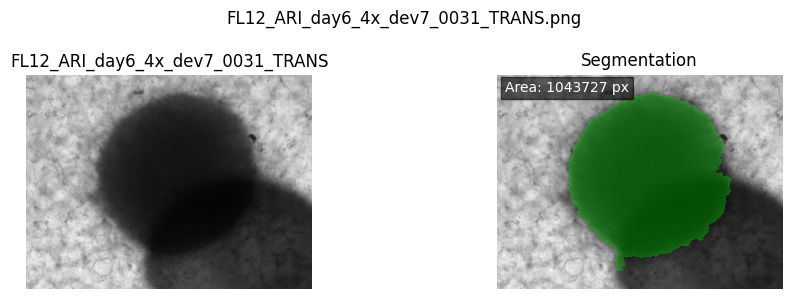

image FL12_ULA_day6_4x_dev1_0038_TRANS.png: method=Segmentation, solidity=0.925, area=1073440 px


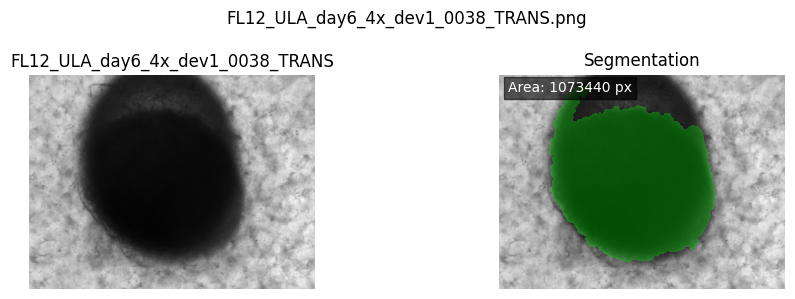

image FL12_ULA_day6_4x_dev2_0039_TRANS.png: method=Segmentation (Extra Opening), solidity=0.942, area=801607 px


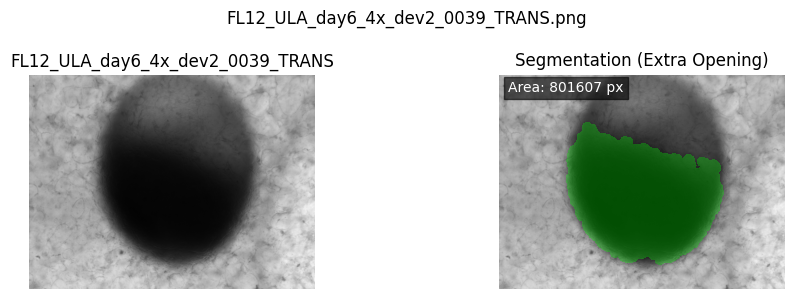

image FL12_ULA_day6_4x_dev3_0040_TRANS.png: method=Segmentation (Extra Opening), solidity=0.922, area=97458 px


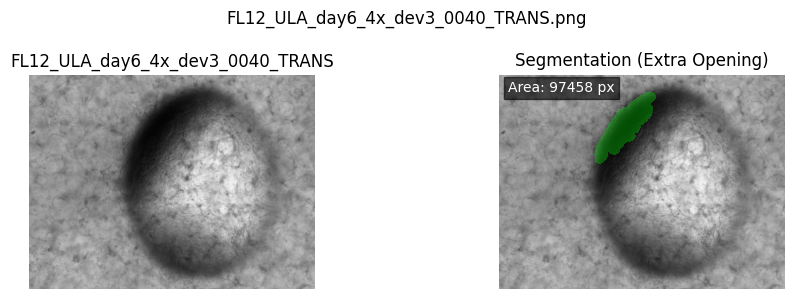

image FL12_ULA_day6_4x_dev4_0041_TRANS.png: method=Segmentation, solidity=0.947, area=1175429 px


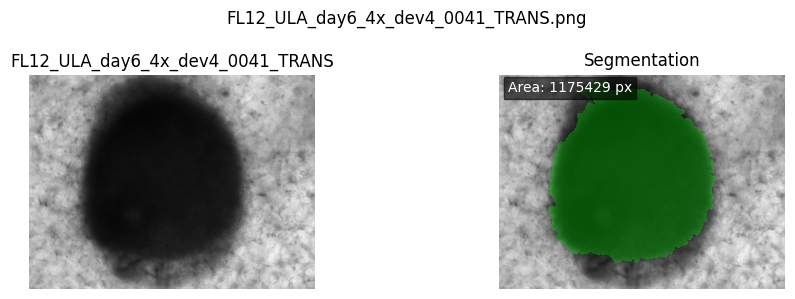

image FL12_ULA_day6_4x_dev5_0042_TRANS.png: method=Segmentation, solidity=0.957, area=1090902 px


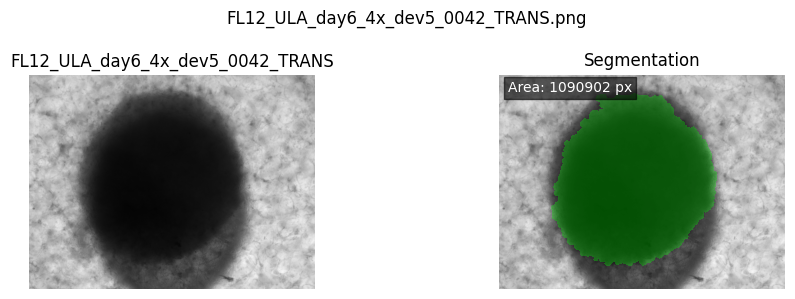

image FL12_ULA_day6_4x_dev6_0043_TRANS.png: method=Segmentation, solidity=0.959, area=754238 px


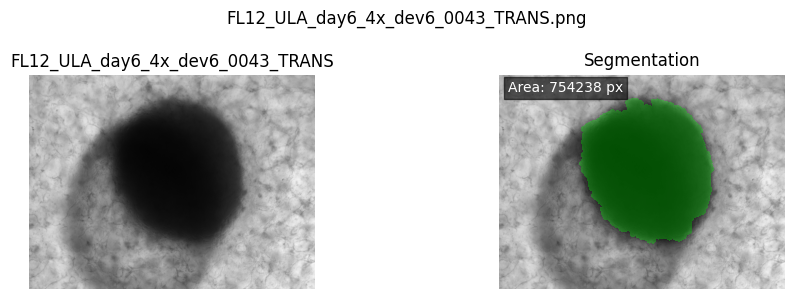

image FL12_ULA_day6_4x_dev7_0044_TRANS.png: method=Segmentation, solidity=0.967, area=1130237 px


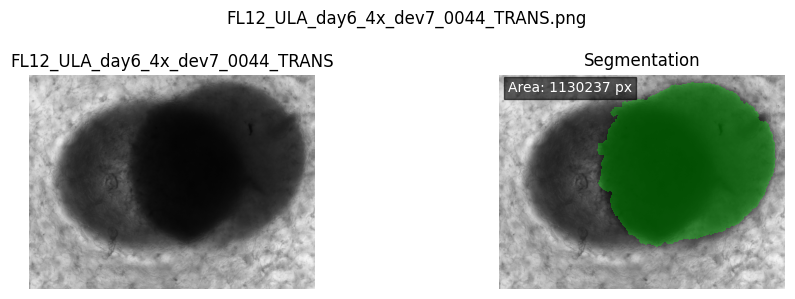

image FL32_ARI_day6_2x_dev1_0014_TRANS.png: method=Segmentation, solidity=0.978, area=963220 px


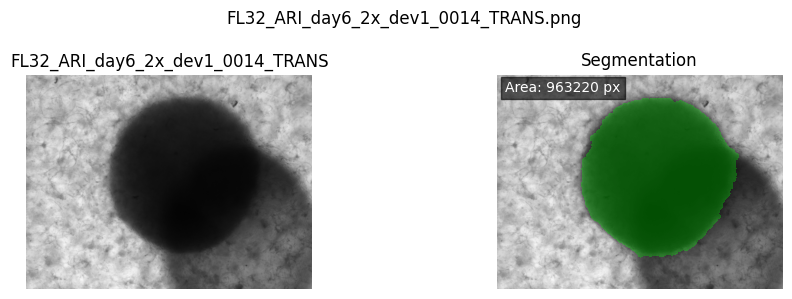

image FL32_ARI_day6_2x_dev2_0016_TRANS.png: method=Segmentation, solidity=0.931, area=783909 px


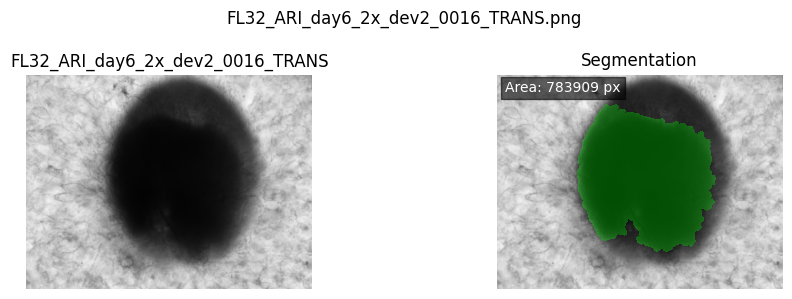

image FL32_ARI_day6_4x_dev3_0017_TRANS.png: method=Segmentation, solidity=0.922, area=870873 px


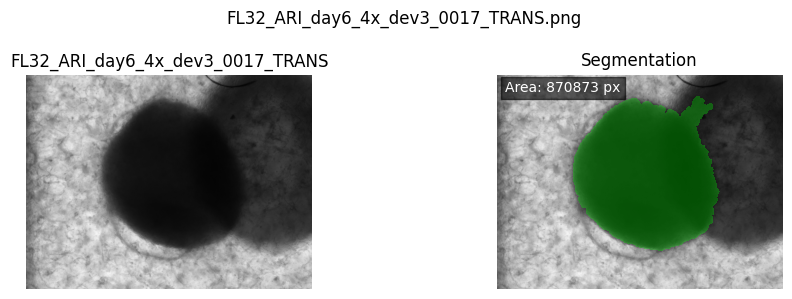

image FL32_ARI_day6_4x_dev4_0019_TRANS.png: method=Segmentation, solidity=0.972, area=988885 px


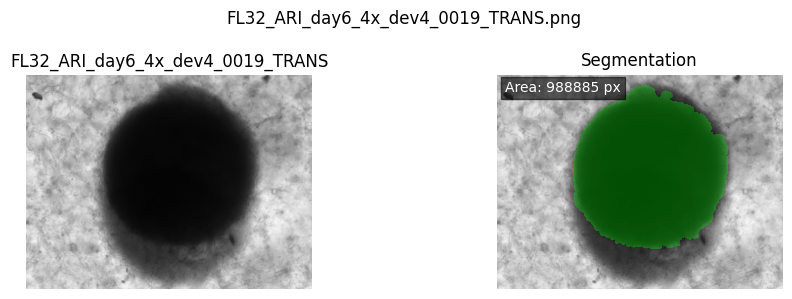

image FL32_ARI_day6_4x_dev5_0020_TRANS.png: method=Segmentation, solidity=0.978, area=1044982 px


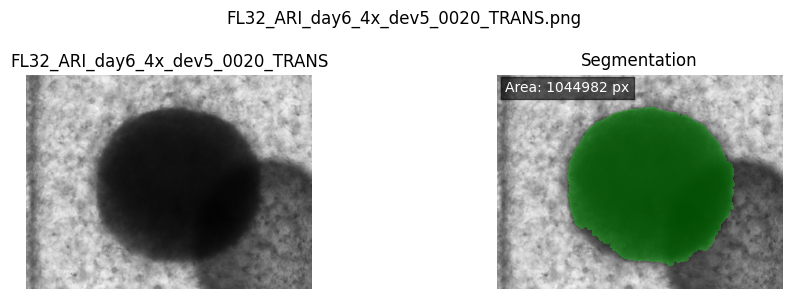

image FL32_ARI_day6_4x_dev6_0021_TRANS.png: method=Segmentation, solidity=0.941, area=824063 px


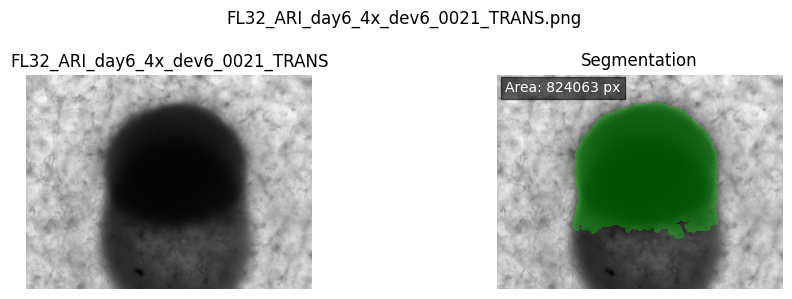

image FL32_ARI_day6_4x_dev7_0022_TRANS.png: method=Segmentation, solidity=0.925, area=846461 px


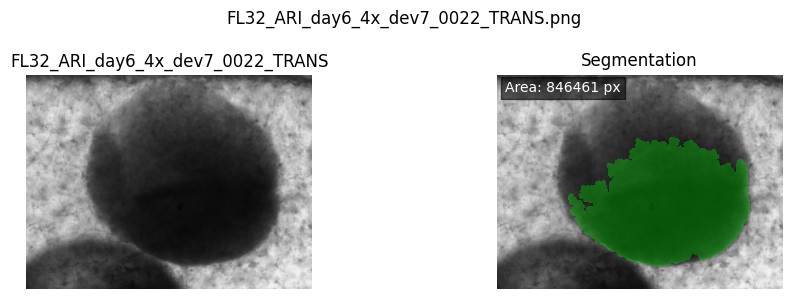

image FL32_UTD_day6_4x_dev1_0024_TRANS.png: method=Segmentation, solidity=0.950, area=867937 px


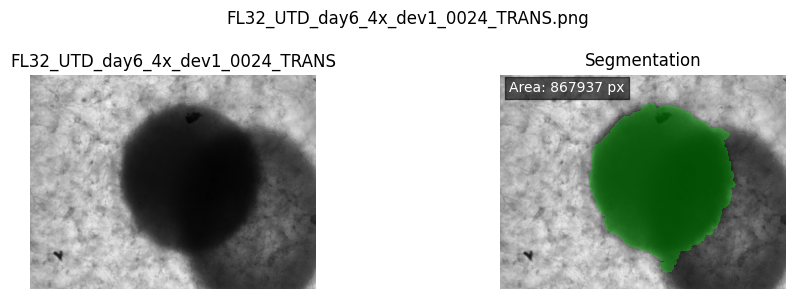

image FL32_UTD_day6_4x_dev2_0025_TRANS.png: method=Segmentation (Extra Opening), solidity=0.950, area=1074163 px


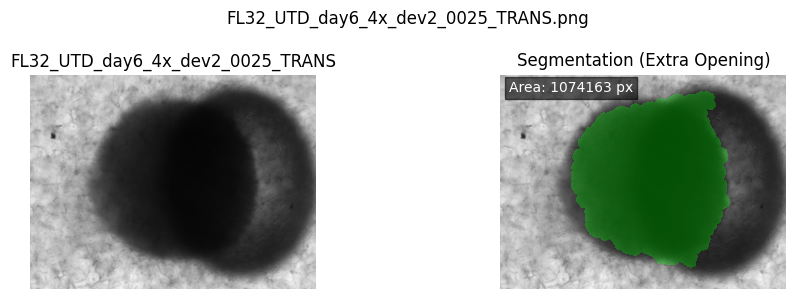

image FL32_UTD_day6_4x_dev3_0026_TRANS.png: method=Segmentation, solidity=0.946, area=991099 px


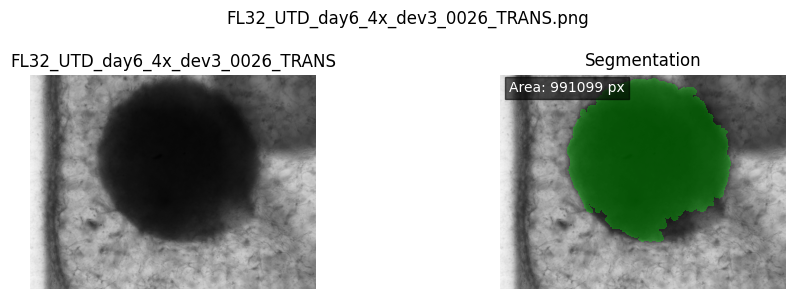

image FL32_UTD_day6_4x_dev4_0027_TRANS.png: method=Segmentation, solidity=0.972, area=1068953 px


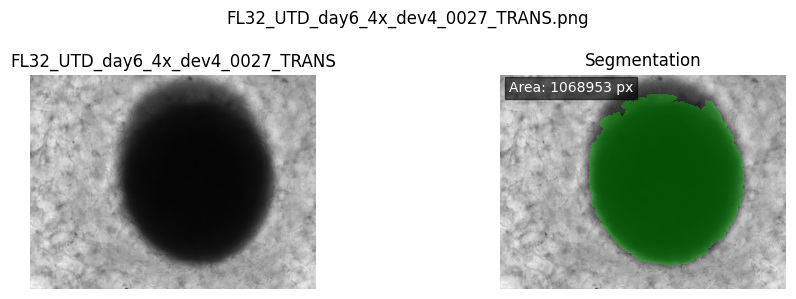

image FL32_UTD_day6_4x_dev5_0028_TRANS.png: method=Segmentation, solidity=0.954, area=830871 px


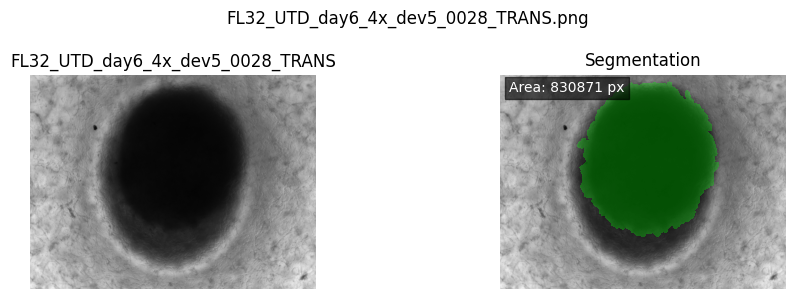

image FL32_UTD_day6_4x_dev6_0029_TRANS.png: method=Segmentation (Extra Opening), solidity=0.861, area=592729 px


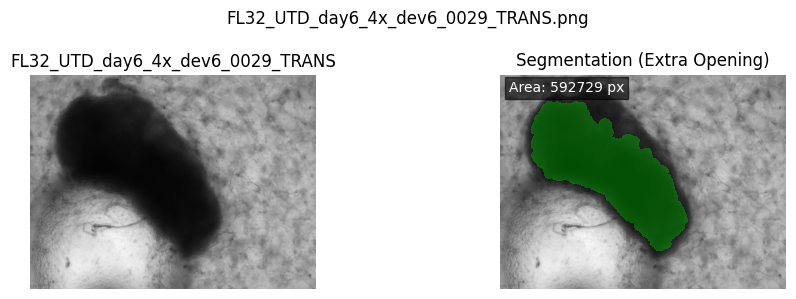

image FL32_UTD_day6_4x_dev7_0030_TRANS.png: method=Segmentation, solidity=0.966, area=610518 px


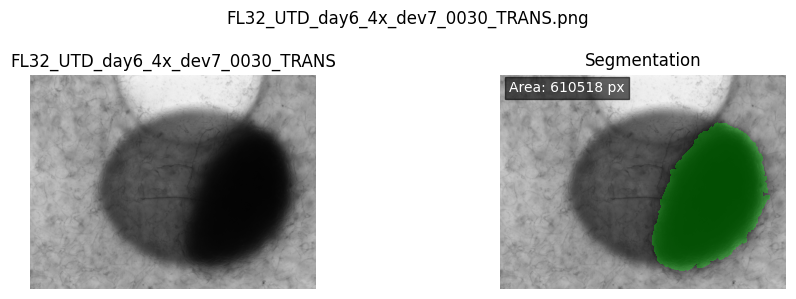

Saved organoid area summary to Z:\Bel\Marina_Area_PDO\260310\organoid_areas.csv
Saved segmentation plots to Z:\Bel\Marina_Area_PDO\260310\segmentation_plots


In [11]:
import csv

from skimage.morphology import disk, opening, remove_small_holes

def segment_from_stack_slice(segmented_slice, opening_radius, expand_distance):
    eroded_labels = label(
        remove_small_holes(opening(segmented_slice == 1, disk(opening_radius)), max_size=5000)
    )

    organoid = np.zeros_like(eroded_labels, dtype=bool)
    solidity = np.nan

    if eroded_labels.max() > 0:
        label_sizes = np.bincount(eroded_labels.ravel())
        label_sizes[0] = 0
        organoid = eroded_labels == label_sizes.argmax()
        organoid = remove_small_holes(
            expand_labels(organoid.astype(int), distance=expand_distance) > 0,
            max_size=50000,
        )
        organoid = opening(organoid, disk(5))

        solidity_table = regionprops_table(
            label(organoid),
            properties=("label", "solidity"),
        )
        if len(solidity_table["label"]) > 0:
            solidity = solidity_table["solidity"][0]

    return organoid, solidity


min_solidity_for_pruning = 0.92
default_expand_distance = 15
extra_opening_expand_distance = 25
figure_output_folder = image_folder / "segmentation_plots"
figure_output_folder.mkdir(exist_ok=True)
area_rows = []

for i, image_path in enumerate(images):
    image = imread(image_path)
    image_title = image_path.name
    image_label = image_path.stem
    used_extra_opening = False

    organoid, solidity = segment_from_stack_slice(
        segmented_stack[i, :, :],
        opening_radius=0,
        expand_distance=default_expand_distance,
    )
    method_name = "Segmentation"

    if organoid.any() and not np.isnan(solidity) and solidity < min_solidity_for_pruning:
        organoid, solidity = segment_from_stack_slice(
            segmented_stack[i, :, :],
            opening_radius=10,
            expand_distance=extra_opening_expand_distance,
        )
        method_name = "Segmentation (Extra Opening)"
        used_extra_opening = True
    elif not organoid.any():
        method_name = "Segmentation"

    organoid_area = int(organoid.sum())
    area_rows.append({
        "image_name": image_title,
        "organoid_area_px": organoid_area,
    })

    print(
        f"image {image_title}: method={method_name}, solidity={solidity:.3f}, area={organoid_area} px"
    )

    fig, ax = plt.subplots(ncols=2, figsize=(10, 3))
    fig.suptitle(image_title)

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title(image_label)

    ax[1].imshow(image, cmap="gray")
    ax[1].imshow(
        organoid.astype(int),
        cmap=ListedColormap(["black", "lime"]),
        alpha=np.where(organoid, 0.3, 0.0),
        interpolation="none",
    )
    ax[1].text(
        0.03,
        0.97,
        f"Area: {organoid_area} px",
        transform=ax[1].transAxes,
        ha="left",
        va="top",
        color="white",
        bbox={"facecolor": "black", "alpha": 0.6, "pad": 3},
    )
    ax[1].set_title(method_name)

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    figure_path = figure_output_folder / f"{image_label}_segmentation.png"
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

csv_path = image_folder / "organoid_areas.csv"
with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=["image_name", "organoid_area_px"])
    writer.writeheader()
    writer.writerows(area_rows)

print(f"Saved organoid area summary to {csv_path}")
print(f"Saved segmentation plots to {figure_output_folder}")